# Do the cicadas ring the bell for stocks? 🦗📈
### The "17-year cicada bull" — a fixed, famous calendar that means absolutely nothing

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cicada_indicator%3F: Busted](https://img.shields.io/badge/Cicada_indicator%3F-Busted-8b949e?style=flat-square)

Every 13 or 17 years, billions of periodical cicadas claw out of the ground across the eastern US, sing deafeningly for six weeks, and blanket the news. It's one of the few genuinely *fixed* events in nature — the year of the next emergence has been known, to the year, since the last one. So it makes an irresistible bit of market folklore: two of the biggest emergences (2004 and 2021) landed in rising markets, and *voilà*, a "cicada indicator."

This study is a **deliberate joke with a serious payoff.** There's no reason on earth cicadas should move the S&P 500 — so we build the *strongest* version of the claim, run the exact same rigorous event study we'd run on a real effect, and watch it come back empty. It's the cleanest way to show what a genuine null looks like — and how easily a coincidence dresses up as a signal.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the beta-vs-alpha timer? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> 🔬 **For the quants:** the event unit is the emergence *year* (independent, non-overlapping), so the primary is a one-sample *t* across years, not a daily panel — and the tradability grade is the **excess over the every-spring baseline** (alpha), never the raw return vs zero (which is just equity beta).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cicada_brood import data, strategy as st

BROODS = data.brood_table()
EV_YEARS = data.brood_years()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY = data.load_real()
    RET = st.daily_returns(SPY)
    AR = st.abnormal_returns(RET)
    POOL = data.all_years(SPY)
else:
    SPY = RET = AR = POOL = None
print("real cache present:", HAVE_REAL, "| brood rows:", len(BROODS),
      "| distinct emergence years:", len(EV_YEARS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_broods': 30, 'cal_lo': 1996, 'cal_hi': 2025, 'n_events': 24, 'span': 30, 'brood_years_in_span': 24, 'pool_years': 33, 'spy_rows': 8411, 'K': 42, 'KS': 21, 'cut_all': (24, 2.4, 0.385, 0.37, 18, 24, 75, 55, 88), 'cut_17': (23, 2.626, 0.607, 0.57, 18, 23, 78, 58, 90), 'cut_fam': (5, 3.755, 1.706, 1.19, 5, 5, 100, 57, 100), 'baseline_bps': 180.1, 'cicada_mean_bps': 240.0, 'cicada_minus_base_bps': 60.0, 'placebo_obs_pct': 2.4, 'placebo_mean_pct': 1.802, 'placebo_sd_pct': 0.606, 'placebo_p': 0.165, 'placebo_draws': 20000, 'short_abn_pct': 0.142, 'short_abn_t': 0.2, 'welch_cicada_pct': 2.4, 'welch_non_pct': 0.201, 'welch_non_n': 9, 'welch_t': 0.874, 'anat': {0: (0.304, 1.52), 10: (0.517, 0.92), 21: (0.142, 0.2), 31: (0.444, 0.45), 42: (0.385, 0.37)}, 'timer_gross': (240.0, 75, 2.25, 60.0, 0.56), 'timer_net5': (230.0, 71, 2.15, 50.0, 0.47), 'timer_net10': (220.0, 71, 2.06, 40.0, 0.37), 'syn_null_mean': 0.15, 'syn_null_sd': 0.93, 'syn_null_fire': 1, 'syn_planted_t': 4.46, 'syn_planted_pct': 4.79, 'fp_spy': 'a11dcd0a0a72'}


real cache present: True | brood rows: 30 | distinct emergence years: 24


## The answer first

| Question | Answer |
|---|---|
| Do cicada-emergence springs beat ordinary springs for the S&P 500? | **No.** The average cicada spring runs a statistically-nothing **+0.39%** *abnormal* return (*t* = +0.37); a random calendar of springs beats it about **1 time in 6** (placebo *p* = 0.17). |
| But 75% of cicada springs were up! | Sure — and so are most springs. Stocks drift up; a coin weighted to heads isn't a cicada effect. |
| The 5 *famous* broods were 5-for-5 up — isn't that something? | That's **selection**, the exact trick that mints folklore: pick the 5 emergences everyone remembers and you've picked 5 up markets after the fact. |
| Could you trade it? | **No.** You could schedule the trade decades ahead (the one signal with zero look-ahead) and *still* earn only the market's ordinary drift — the edge over just-hold-every-spring is **+60 bps at *t* = 0.56**. |

> The whole point: a fixed, famous, foreseeable natural calendar produces exactly the noise you'd expect it to. This is what an honest *nothing* looks like.

## 1 · The claim

> *"Periodical cicadas emerge on a rigid 13- or 17-year clock — you know the year decades in advance. The big emergences coincided with strong markets (Brood X in 2004 and 2021, both up years). A savvy almanac-reader could position for the 'cicada bull' well ahead of time."*

This is folklore in the grand tradition of the **Super Bowl indicator**, the **January barometer** and **"Sell in May and Go Away"** — impressive-looking calendar coincidences with no mechanism attached. We're not strawmanning it; we're giving it its best shot: a real, precisely-dated, nationally-famous calendar, and the full event-study treatment.

## 2 · So what?

If a calendar this arbitrary *did* predict returns, it would be a gift — a signal you could set and forget, no news to watch, no look-ahead to worry about. It would also be a small scandal for market efficiency: prices moving on *bugs*. So the stakes are really about **method**: this is the desk's control experiment. If our apparatus can be talked into seeing a signal in cicadas, it can be talked into anything — and if it correctly says "nothing here," that's the reassurance that makes the *real* studies trustworthy.

## 3 · How would we even know?

- **The calendar.** **30** mapped periodical-cicada brood emergences 1996–2025, from the University of Connecticut brood chart — **24 distinct emergence years** (the unit we test).
- **The window.** Cicadas surface in early-mid May and swarm through late June, so each event is the S&P 500's **May–June** window (first session after May 1, held ~2 months).
- **The comparison.** That window's *abnormal* return (above the market's own average drift) — and the same window drawn from **random years**, 20,000 times, to see if cicada springs stand out.
- **The base-rate check.** How many of the last 30 years even *had* a brood? (Spoiler: **24 of 30**.)
- **The trade check.** Hold the S&P for the cicada spring only — scheduled years ahead — pay costs, and compare to just holding *every* spring.

## 4 · The teardown — let's actually look

**First, the headline.** Average cicada-spring S&P return vs. what a random spring looks like (same May–June window, so this isn't just the seasonal "Sell in May" pattern).

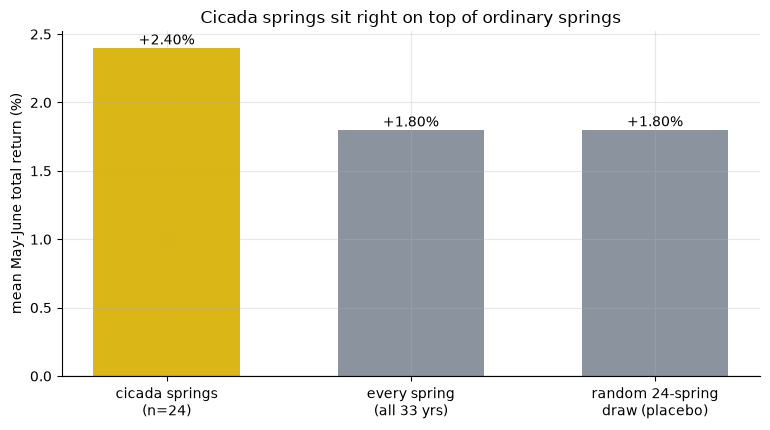

cicada +2.40%  vs  every-spring baseline +1.80%  (placebo p = 0.165 over 20,000 draws)


In [2]:
if HAVE_REAL:
    evt = st.build_event_table(SPY, AR, EV_YEARS, k=R['K'])
    obs = float(evt['raw_ret'].mean()) * 100
    base = st.unconditional_spring_baseline(SPY, POOL, k=R['K']) / 100
else:
    obs, base = R['placebo_obs_pct'], R['baseline_bps'] / 100
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['cicada springs\n(n=24)', 'every spring\n(all 33 yrs)',
        'random 24-spring\ndraw (placebo)'],
       [obs, base, R['placebo_mean_pct']], color=[AMBER, GREY, GREY], width=.6)
for i, v in enumerate([obs, base, R['placebo_mean_pct']]):
    ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean May-June total return (%)')
ax.set_title('Cicada springs sit right on top of ordinary springs')
plt.tight_layout(); plt.show()
print(f'cicada {obs:+.2f}%  vs  every-spring baseline {base:+.2f}%  '
      f"(placebo p = {R['placebo_p']:.3f} over {R['placebo_draws']:,} draws)")

The cicada-spring bar (**+2.40%**) is a whisker above the every-spring bar (**+1.80%**) — about **+60 bps** — but a random draw of 24 springs produces a gap that big **16%** of the time. That's not a signal; that's what noise looks like.

**Next, the trick that fools everyone: the up-rate.** 75% of cicada springs were up. Sounds like a lot — until you remember stocks mostly go up, and you watch what happens when you cherry-pick the *famous* broods.

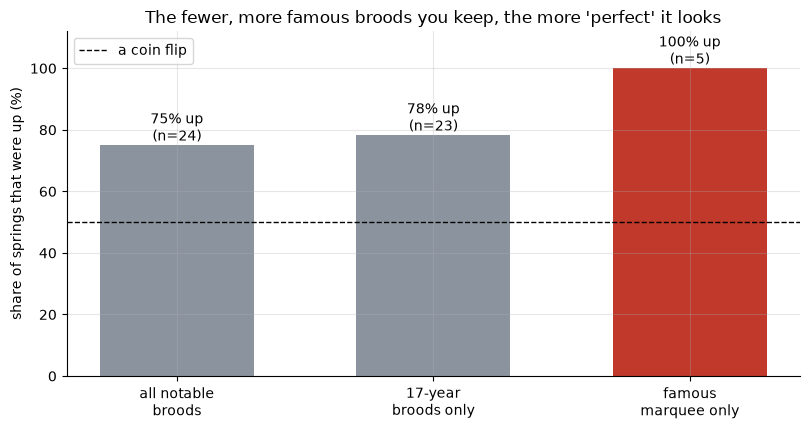

up-rates: {'all': 75, '17yr': 78, 'famous': 100}


In [3]:
labels = ['all notable\nbroods', '17-year\nbroods only', 'famous\nmarquee only']
if HAVE_REAL:
    cuts = []
    for yrs in (EV_YEARS, data.brood_years(cycle=17),
                data.brood_years(famous_only=True)):
        e = st.build_event_table(SPY, AR, yrs, k=R['K'])
        hr = st.hit_rate(e['raw_ret'].to_numpy())
        cuts.append((hr['rate'] * 100, hr['n']))
else:
    cuts = [(R['cut_all'][6], R['cut_all'][0]),
            (R['cut_17'][6], R['cut_17'][0]),
            (R['cut_fam'][6], R['cut_fam'][0])]
rates = [c[0] for c in cuts]; ns = [c[1] for c in cuts]
fig, ax = plt.subplots(figsize=(8.2, 4.4))
cols = [GREY, GREY, RED]
ax.bar(labels, rates, color=cols, width=.6)
for i, (v, n) in enumerate(zip(rates, ns)):
    ax.annotate(f'{v:.0f}% up\n(n={n})', (i, v), ha='center', va='bottom')
ax.axhline(50, ls='--', c='k', lw=1, label='a coin flip')
ax.set_ylim(0, 112); ax.set_ylabel('share of springs that were up (%)')
ax.set_title('The fewer, more famous broods you keep, the more \'perfect\' it looks')
ax.legend(); plt.tight_layout(); plt.show()
print('up-rates:', dict(zip(['all','17yr','famous'], [round(r) for r in rates])))

See the illusion form in real time. All 24 broods: **75% up**. Keep only the marquee ones everyone remembers (2004, 2007, 2013, 2021, 2024): **100% up — 5 for 5**. That looks like destiny. It's **selection**: those five happened to fall in up springs, and picking them *after* the fact is the entire recipe for a market myth. With only 5 events, even a coin lands 5 heads about 1 time in 30.

**Finally, the trade.** Cicada years are the one signal you could schedule decades ahead — zero look-ahead. So does the trade pay?

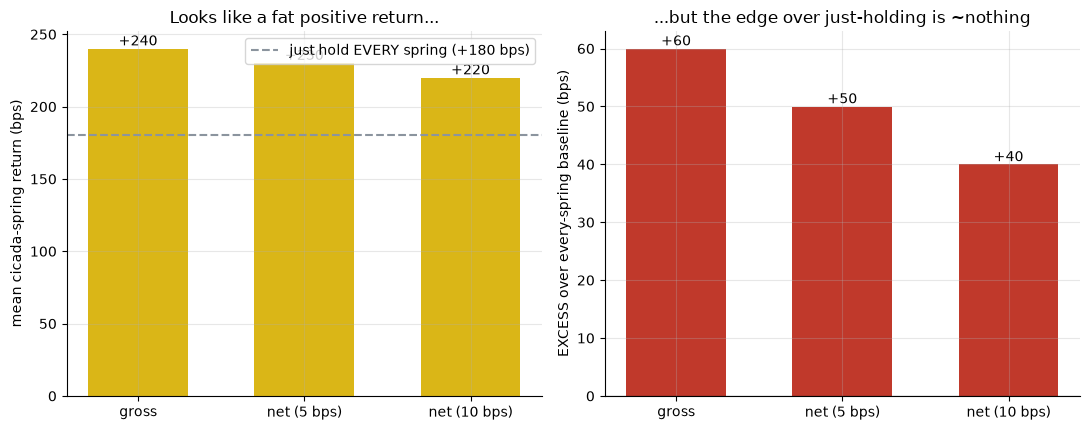

cicada-spring mean (bps): [240, 230, 220]
excess over baseline (bps): [60, 50, 40]


In [4]:
legs = ['gross', 'net (5 bps)', 'net (10 bps)']
if HAVE_REAL:
    means, excess = [], []
    for cost in (0.0, 5.0, 10.0):
        lg = st.spring_timer(SPY, EV_YEARS, k=R['K'], cost_bps=cost)
        col = 'ret_gross' if cost == 0 else 'ret_net'
        means.append(st.summarize_timer(lg, col=col)['mean_bps'])
        excess.append(st.excess_over_baseline(SPY, EV_YEARS, POOL,
                       k=R['K'], cost_bps=cost)['excess_bps'])
    base_bps = st.unconditional_spring_baseline(SPY, POOL, k=R['K'])
else:
    means = [R['timer_gross'][0], R['timer_net5'][0], R['timer_net10'][0]]
    excess = [R['timer_gross'][3], R['timer_net5'][3], R['timer_net10'][3]]
    base_bps = R['baseline_bps']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
a1.bar(legs, means, color=AMBER, width=.6)
a1.axhline(base_bps, ls='--', c=GREY, lw=1.5,
           label=f'just hold EVERY spring ({base_bps:+.0f} bps)')
for i, v in enumerate(means):
    a1.annotate(f'{v:+.0f}', (i, v), ha='center', va='bottom')
a1.set_ylabel('mean cicada-spring return (bps)')
a1.set_title('Looks like a fat positive return...'); a1.legend()
a2.bar(legs, excess, color=RED, width=.6)
a2.axhline(0, c='k', lw=.8)
for i, v in enumerate(excess):
    a2.annotate(f'{v:+.0f}', (i, v), ha='center', va='bottom')
a2.set_ylabel('EXCESS over every-spring baseline (bps)')
a2.set_title('...but the edge over just-holding is ~nothing')
plt.tight_layout(); plt.show()
print('cicada-spring mean (bps):', [round(v) for v in means])
print('excess over baseline (bps):', [round(v) for v in excess])

On the left, the cicada trade earns a chunky-looking **+240 bps** — but that's just what holding *any* two months of stocks earns on average. The honest question is the panel on the right: how much does cicada-timing beat *just holding every spring*? **+60 bps gross**, shrinking with costs — a rounding error, not an edge. You waited 17 years for the bugs and the market handed you the same beta it hands everyone.

## 5 · The verdict

- **Signal — None.** Cicada-spring abnormal return **+0.39%** (*t* = +0.37), placebo *p* = 0.17. The 75% up-rate and the 5/5 famous-brood streak are drift and selection, not a cicada effect.
- **Tradability — Mirage.** A perfectly-foreseeable calendar trade whose edge over just-holding-every-spring is **+60 bps (*t* = 0.56)** — pure beta.
- **"Cicada indicator?" — Busted.** A brood emerges in **24 of 30** recent years; "cicada years" are nearly the whole calendar. Exactly the nothing we built the study to find.

## 6 · Going further 🚪

- **This is the desk's control experiment.** It exists to be *negative* — to show the same apparatus that grades real anomalies returns an honest zero on a pattern with no mechanism. If you ever see this rig hand a cicada calendar a green stamp, something is broken.
- **The look-elsewhere lesson generalises.** Any fixed, evocative calendar (full moons, election years, leap years, World Cups) can be mined for a 5-for-5 streak in a bull market. The fix isn't a cleverer test on the same data — it's out-of-sample data and a pre-registered window.
- **Sibling studies:** [707-plane-crash-effect](../../707-plane-crash-effect/) and [708-eurovision-effect](../../708-eurovision-effect/) — same machinery (hardcoded calendar, event study, placebo, costed timer), real sentiment triggers instead of a pure coincidence. Cicada-Brood is their deliberately absurd cousin.

*Think a different fixed calendar hides a real edge? Pre-register the window, bring out-of-sample years, grade it on excess-over-baseline after costs — then we'll talk.*